(Planned)

Figure 1. Conceptual Diagram of an IMAS/IDS-based Integrated Workflow (CH 1)

Figure 2. Overall Architecture of the VEST Integrated Platform (CH 2)

Figure 3. VEST 2D Poloidal Geometry for Electromagnetic Modeling (CH 3)

<repo>/vaft/omas/__init__.py:111: RuntimeWarning: Could not infer an IMAS DD version for omas_json; using 3.41.0


2026-08-30 22:02:18,810 - vaft.omas.process_wrapper - INFO - Computing grid response (Psi)...


2026-08-30 22:02:18,823 - vaft.omas.process_wrapper - INFO - Processing 10 active coils...


2026-08-30 22:02:23,657 - vaft.omas.process_wrapper - INFO - Coil contributions complete.


2026-08-30 22:02:23,680 - vaft.omas.process_wrapper - INFO - Processing 1 passive loops...


2026-08-30 22:02:23,703 - vaft.omas.process_wrapper - INFO - Loop contributions complete.


2026-08-30 22:02:23,707 - vaft.omas.process_wrapper - INFO - Grid response computation complete.


(<Figure size 600x700 with 2 Axes>,
 <Axes: title={'center': 'Vacuum psi at t = 330.7 ms'}, xlabel='R [m]', ylabel='Z [m]'>)

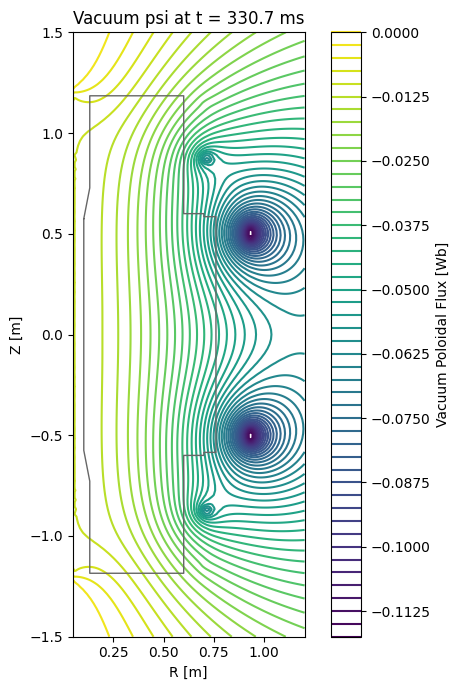

In [ ]:
import vaft
sample_path = vaft.data.sample(39915, representation="omas")
ods = vaft.omas.load(sample_path)
vaft.omas.plot_equilibrium_field_psi_vacuum(ods)

In [ ]:
from omas import *
import vaft
import matplotlib.pyplot as plt


# matplotlib 설정 개선
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 20


# ods = vaft.omas.load(vaft.data.sample(39915, representation="omas"))
# vaft.omas.plot_equilibrium_field_psi_vacuum(ods)

PastedGraphic-1.png

Figure 4. Equilibrium Refinement using CHEASE

In [ ]:
from pathlib import Path
import itertools
import os

from omas import *
import vaft
import matplotlib.pyplot as plt
import numpy as np
from vaft.data import read_geqdsk
from vaft.data.resources import data_path

shot = 41606
time_ms = 329
time_s = time_ms / 1000.0

filedb_root = Path(os.environ.get('VAFT_FILEDB_DIR', 'FileDB')).expanduser()
chease_path = filedb_root / 'chease' / str(shot) / f'g0{shot}.00{time_ms}'
efit_path = filedb_root / 'efit' / str(shot) / 'gfile' / f'g0{shot}.00{time_ms}'
if not chease_path.exists():
    chease_path = data_path('efit/g039915.00319')
if not efit_path.exists():
    efit_path = data_path('efit/g039915.00319')


def ensure_j_tor(ods):
    prof = ods['equilibrium.time_slice.0.profiles_1d']
    if 'j_tor' not in prof:
        prof['j_tor'] = np.zeros_like(np.asarray(prof['rho_tor_norm'], dtype=float))
    return ods

eq_chease = read_geqdsk(chease_path)
ods_chease = ensure_j_tor(eq_chease.to_omas())
if 'equilibrium.time_slice.0.profiles_1d.j_tor' in ods_chease:
    ods_chease['equilibrium.time_slice.0.profiles_1d.j_tor'] = abs(ods_chease['equilibrium.time_slice.0.profiles_1d.j_tor'])
eq = read_geqdsk(efit_path)
ods_efit = ensure_j_tor(eq.to_omas())


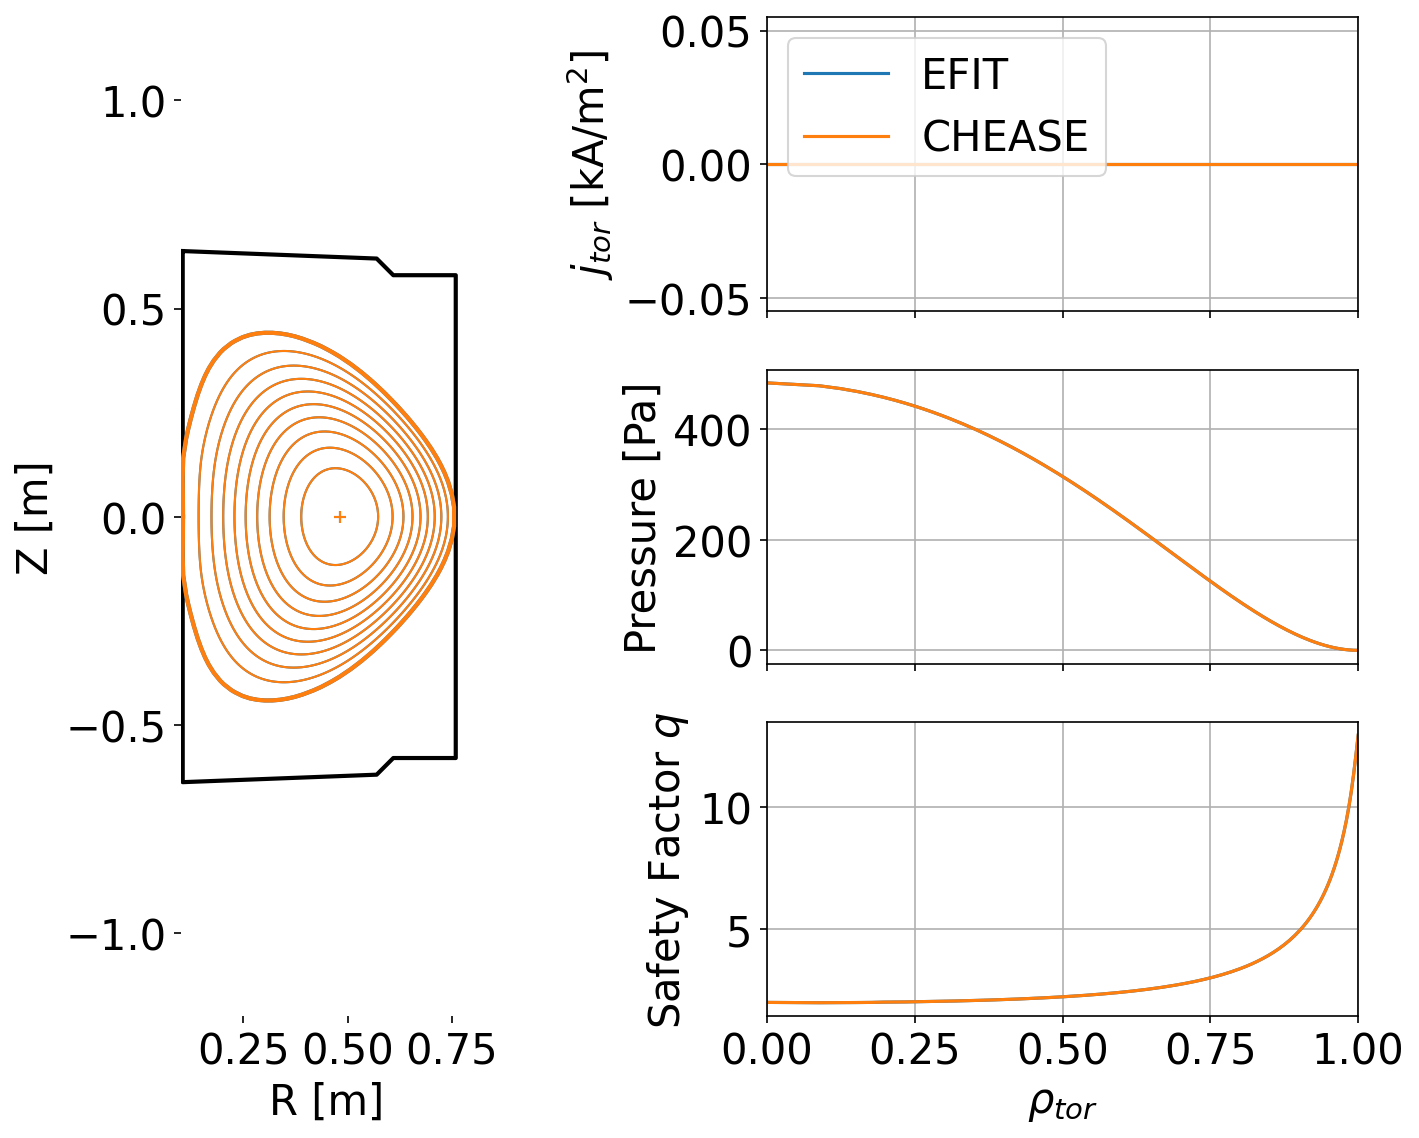

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from omas import *
from vaft.data import read_geqdsk
import copy
import numpy as np
from matplotlib import pyplot as plt, patches, path
from omas.omas_utils import omas_interp1d        # same helper the original code used
from omas.omas_plot import handle_time                 # same helper the original code used
from omas.omas_physics import grids_ggd_points_triangles # optional caching (unchanged)

# ────────────────────────────────────────
# 1. wall-only plotter
# ────────────────────────────────────────
def draw_wall(ods, time_index=None, ax=None, **kw):
    """
    Plot the limiter / first-wall outline only.

    Parameters
    ----------
    ods : ODS
    time_index : int or None
    ax : matplotlib.axes.Axes or None
    **kw : forwarded to ax.plot

    Returns
    -------
    matplotlib.axes.Axes
    """
    if ax is None:
        ax = plt.gca()

    time_index, _ = handle_time(ods, 'wall', time_index, None)

    wall = None
    if 'wall' in ods:
        if time_index in ods['wall']['description_2d']:
            wall = ods['wall']['description_2d'][time_index]['limiter']['unit']
        elif 0 in ods['wall']['description_2d']:
            wall = ods['wall']['description_2d'][0]['limiter']['unit']
    if wall is None:
        raise ValueError('No wall data in ODS')

    kw.setdefault('color', 'k')
    kw.setdefault('linewidth', 2)
    ax.plot(wall[0]['outline']['r'], wall[0]['outline']['z'], **kw)

    ax.set_aspect('equal')
    ax.set_frame_on(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    return ax


# ────────────────────────────────────────
# 2. flux-surface / contour plotter
# ────────────────────────────────────────
def draw_flux(
    ods,
    time_index=None,
    time=None,
    levels=None,
    contour_quantity='rho_tor_norm',
    allow_fallback=True,
    ax=None,
    sf=3,
    label_contours=None,
    xkw=None,
    ggd_points_triangles=None,
    clip_to_lcfs=False,
    **kw,
):
    """
    Plot boundary, magnetic axis, and flux-surface contours.

    All arguments mirror the original `equilibrium_CX`, except:
    - No wall is drawn.
    - Optional `clip_to_lcfs` masks everything outside the LCFS.
    """
    import scipy.ndimage

    if xkw is None:
        xkw = {}

    if ax is None:
        ax = plt.gca()

    # handle multiple timeslices
    time_index, time = handle_time(ods, 'equilibrium', time_index, time)
    if isinstance(time_index, (list, np.ndarray)):
        if len(time) == 1:
            time_index = time_index[0]
        else:  # simple loop; user can animate externally if needed
            for ti in time_index:
                draw_flux(
                    ods,
                    time_index=ti,
                    levels=levels,
                    contour_quantity=contour_quantity,
                    allow_fallback=allow_fallback,
                    ax=ax,
                    sf=sf,
                    label_contours=label_contours,
                    xkw=xkw,
                    ggd_points_triangles=ggd_points_triangles,
                    clip_to_lcfs=clip_to_lcfs,
                    **kw,
                )
            return ax

    eq = ods['equilibrium']['time_slice'][time_index]

    # boundary curve
    kw_boundary = copy.deepcopy(kw)
    kw_boundary.setdefault('linewidth', kw_boundary.pop('linewidth', 1) + 1)
    boundary_line, = ax.plot(
        eq['boundary.outline.r'], eq['boundary.outline.z'], **kw_boundary
    )
    default_color = boundary_line.get_color()

    # magnetic axis
    if 'global_quantities.magnetic_axis.r' in eq and 'global_quantities.magnetic_axis.z' in eq:
        ax.plot(
            eq['global_quantities']['magnetic_axis']['r'],
            eq['global_quantities']['magnetic_axis']['z'],
            '+',
            color=default_color,
            lw=kw_boundary['linewidth'],
        )

    # prepare 2-D data getter
    def _get2d(q):
        if 'profiles_2d' in eq and f'profiles_2d.0.{q}' in eq:
            return eq[f'profiles_2d.0.{q}']
        if f'ggd.0.{q}.0.values' in eq:
            return eq[f'ggd.0.{q}.0.values']
        return None

    # pick quantity
    for _ in range(2):
        if (
            _get2d('psi') is not None
            and 'psi' in eq['profiles_1d']
            and contour_quantity in eq['profiles_1d']
            or contour_quantity == 'psi_norm'
        ):
            x1d = eq['profiles_1d']['psi']
            m, M = x1d[0], x1d[-1]
            x1d = (x1d - m) / (M - m)
            x2d = (_get2d('psi') - m) / (M - m)
            v1d = x1d if contour_quantity == 'psi_norm' else eq['profiles_1d'][contour_quantity]
            v2d = omas_interp1d(x2d, x1d, v1d)
            break
        if _get2d(contour_quantity) is not None:
            v1d = None
            v2d = _get2d(contour_quantity)
            break
        if allow_fallback and allow_fallback != contour_quantity:
            contour_quantity = allow_fallback
        else:
            raise ValueError(f'No {contour_quantity} data in ODS')

    # default levels
    if levels is None and v1d is not None:
        if contour_quantity == 'q':
            max_q = int(np.round(omas_interp1d(0.95, x1d, v1d)))
            levels = np.arange(abs(max_q))
            if max_q < 0:
                levels *= -1
                levels = levels[::-1]
        else:
            levels = np.linspace(np.nanmin(v1d), np.nanmax(v1d), 11)[1:-1]

    # grid
    if 'profiles_2d.0' in eq:
        if 'r' in eq['profiles_2d.0'] and 'z' in eq['profiles_2d.0']:
            r = eq['profiles_2d.0.r']
            z = eq['profiles_2d.0.z']
        else:
            z, r = np.meshgrid(eq['profiles_2d.0.grid.dim2'], eq['profiles_2d.0.grid.dim1'])

        v2d = v2d.copy()
        v2d[:, -1] = v2d[:, -2]
        v2d[-1, :] = v2d[-2, :]
        v2d[-1, -1] = v2d[-2, -2]

        if sf > 1:
            v2d[np.isnan(v2d)] = np.nanmean(v2d)
            r = scipy.ndimage.zoom(r, sf)
            z = scipy.ndimage.zoom(z, sf)
            v2d = scipy.ndimage.zoom(v2d, sf)

        cs = ax.contour(r, z, v2d, levels=levels, colors=kw.get('color', default_color), linewidths=kw.get('linewidth', 1))
    else:
        if ggd_points_triangles is None and 'equilibrium.grids_ggd' in ods:
            ggd_points_triangles = grids_ggd_points_triangles(ods['equilibrium.grids_ggd[0].grid[0]'])
        cs = ax.tricontour(
            ggd_points_triangles[0][:, 0],
            ggd_points_triangles[0][:, 1],
            ggd_points_triangles[1],
            v2d,
            levels=levels,
            colors=kw.get('color', default_color),
            linewidths=kw.get('linewidth', 1),
        )

    if label_contours or ((label_contours is None) and contour_quantity == 'q'):
        ax.clabel(cs)

    # clip to LCFS if requested
    if clip_to_lcfs:
        lcfs_path = path.Path(np.column_stack((eq['boundary.outline.r'], eq['boundary.outline.z'])))
        lcfs_patch = patches.PathPatch(lcfs_path, facecolor='none', edgecolor='none')
        ax.add_patch(lcfs_patch)
        if hasattr(cs, 'collections'):
            for c in cs.collections:
                c.set_clip_path(lcfs_patch)
        else:
            cs.set_clip_path(lcfs_patch)


    ax.set_aspect('equal')
    ax.set_frame_on(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    return ax


# --- 두 ODS를 비교하는 새로운 메인 플롯 함수 ---
def plot_equilibrium_summary_comparison(
    ods1, ods2,
    label1='EFIT', label2='CHEASE',
    shotnumber=None, time=None, time_idx=0,
    colors=('C0', 'C1'),
    kwargs1={}, kwargs2={}
):
    """
    두 개의 ODS 객체(예: EFIT, CHEASE)를 겹쳐 그려 비교합니다.

    :param ods1: 첫 번째 ODS 객체
    :param ods2: 두 번째 ODS 객체
    :param label1: 첫 번째 데이터셋의 라벨
    :param label2: 두 번째 데이터셋의 라벨
    :param shotnumber: Shot 번호 (제목용)
    :param time: 시간 (제목용)
    :param time_idx: ODS 내의 time_slice 인덱스
    :param colors: 각 데이터셋에 사용할 색상 튜플
    :param kwargs1: ods1 플롯에 전달할 추가 인자 딕셔너리
    :param kwargs2: ods2 플롯에 전달할 추가 인자 딕셔너리
    """
    fig = plt.figure(figsize=(10, 8))
    gs = GridSpec(nrows=3, ncols=2, width_ratios=[1, 1], figure=fig)

    # --- 왼쪽 플롯 (단면도) ---
    ax_eq = fig.add_subplot(gs[:, 0])
    
    # 첫 번째 ODS 그리기
    
    # ods1.plot_equilibrium_CX(time_index=time_idx, ax=ax_eq, label=label1, color=colors[0], xkw={'marker': ''}, **kwargs1)
    # 두 번째 ODS 겹쳐 그리기
    # ods2.plot_equilibrium_CX(time_index=time_idx, ax=ax_eq, label=label2, color=colors[1], xkw={'marker': ''}, show_wall=False, **kwargs2)
    draw_wall(ods1, time_index=0, ax=ax_eq)
    draw_flux(ods1, time_index=0, contour_quantity='psi_norm', clip_to_lcfs=True, ax=ax_eq)
    draw_flux(ods2, time_index=0, contour_quantity='psi_norm', clip_to_lcfs=True, ax=ax_eq)

    # ax_eq.set_title('Equilibrium Comparison')
    # ax_eq.legend()
    ax_eq.set_xlim(0.1,0.8)
    ax_eq.set_ylim(-1.2, 1.2)
    ax_eq.set_xlabel('R [m]')
    ax_eq.set_ylabel('Z [m]')

    # --- 오른쪽 플롯 (1D 프로파일) ---
    ax_j = fig.add_subplot(gs[0, 1])
    ax_p = fig.add_subplot(gs[1, 1])
    ax_q = fig.add_subplot(gs[2, 1])
    
    axes = [ax_j, ax_p, ax_q]
    profile_keys = ['j_tor', 'pressure', 'q']
    ylabels = [r'$j_{tor}$ [kA/m$^2$]', 'Pressure [Pa]', 'Safety Factor $q$']
    multipliers = [1e-3, 1, 1] # 단위 변환 계수

    for ax, key, ylabel, mult in zip(axes, profile_keys, ylabels, multipliers):
        # ODS 1 프로파일
        prof1 = ods1[f'equilibrium.time_slice.{time_idx}.profiles_1d']
        ax.plot(prof1['rho_tor_norm'], prof1[key] * mult, color=colors[0], label=label1)
        
        # ODS 2 프로파일
        prof2 = ods2[f'equilibrium.time_slice.{time_idx}.profiles_1d']
        ax.plot(prof2['rho_tor_norm'], prof2[key] * mult, color=colors[1], label=label2)
        
        ax.set_ylabel(ylabel, fontsize=20)
        ax.set_xlim(0, 1)
        ax.grid(True)

    # 상단 플롯에만 제목과 범례 추가
    # # title_text = f'1D Profile Comparison'
    # if shotnumber and time:
    #     title_text += f'\nShot = {shotnumber}, Time = {time:.3f} s'
    # ax_j.set_title(title_text, fontsize=14)
    ax_j.legend()
    
    # 중간 플롯까지는 x축 라벨 숨기기
    ax_j.set_xticklabels([])
    ax_p.set_xticklabels([])
    
    # 마지막 플롯에 x축 라벨 표시
    ax_q.set_xlabel(r'$\rho_{tor}$', fontsize=20)

    plt.tight_layout()
    plt.savefig("fig4.png", dpi=600)
    plt.show()

plot_equilibrium_summary_comparison(
            ods1=ods_efit,
            ods2=ods_chease,
            label1='EFIT',
            label2='CHEASE',
            shotnumber=shot,
            time=time_s
        )

Figure 5. Kinetic Profile Reconstruction Process

Figure 6. Comprehensive Analysis of a Representative Discharge (e.g., Shot #41660)

In [ ]:
print('Skipped external VEST_tools / /srv ODS merge section: required files are not available in this environment.')
ods = ods_efit.copy()


Skipped external VEST_tools / /srv ODS merge section: required files are not available in this environment.


Skipped external diagnostics/eddy/CHEASE ODS update section; using local GEQDSK-derived ODS instead.


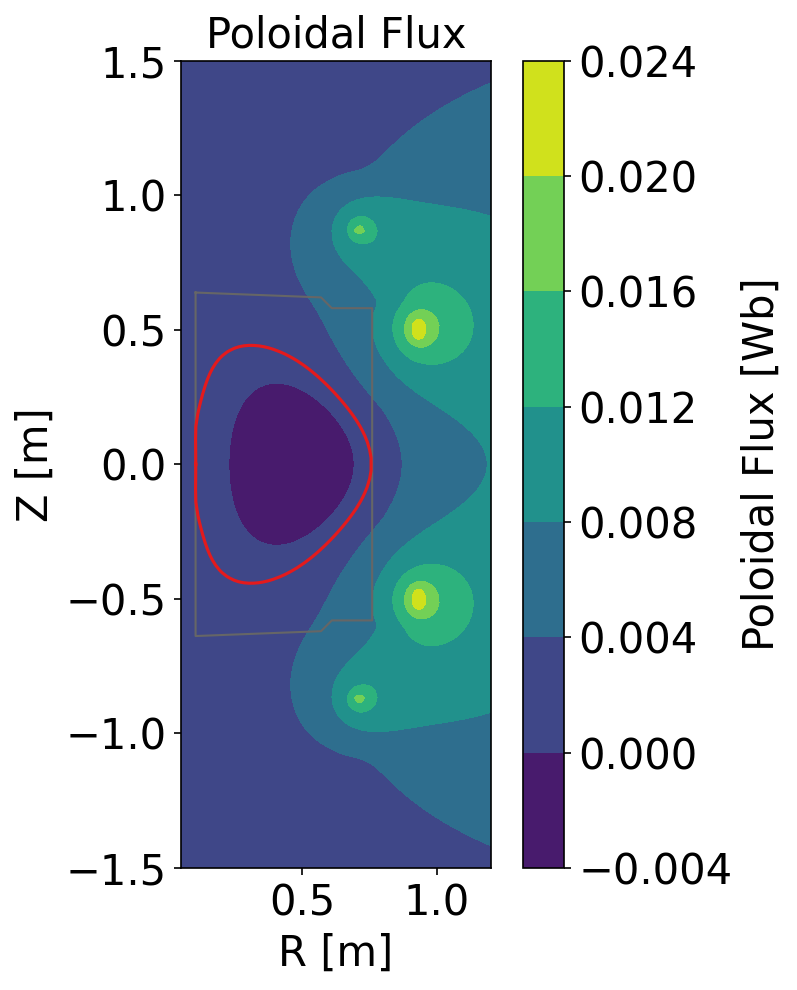

In [ ]:
print('Skipped external diagnostics/eddy/CHEASE ODS update section; using local GEQDSK-derived ODS instead.')
vaft.omas.plot_equilibrium_field_psi(ods)
plt.show()


Figure 7. Statistical Distribution of Key Operational Parameters

In [ ]:
print('Skipped external omas_history_new.xlsx publication scatter section: source Excel file is not available in this environment.')


Skipped external omas_history_new.xlsx publication scatter section: source Excel file is not available in this environment.


Figure 8. Statistical Analysis of VEST Operational Space

In [ ]:
print('Skipped external chease_stability_history.xlsx load section: source Excel file is not available in this environment.')


Skipped external chease_stability_history.xlsx load section: source Excel file is not available in this environment.


In [ ]:
print('Skipped detailed stability-limit plotting demo: external stability dataframe is not available in this environment.')


Skipped detailed stability-limit plotting demo: external stability dataframe is not available in this environment.


In [ ]:
print('Skipped alternate stability-limit plotting demo: external stability dataframe is not available in this environment.')


Skipped alternate stability-limit plotting demo: external stability dataframe is not available in this environment.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_stability_limits_delta_prime_grid(input_file, code, nmode, vmin=None, vmax=None, cmap='viridis'):
    """
    2x2 그리드에 안정성 한계를 플롯하고, 컬러바 위치를 정확하게 조정합니다.
    컬러맵(cmap)과 색상 범위(vmin, vmax)를 인자로 받아 동적으로 설정할 수 있습니다.

    Args:
        input_file (str): 입력 데이터 엑셀 파일 경로.
        code (str): 안정성 코드 이름 (예: 'rdcon', 'stride').
        nmode (int): 토로이달 모드 번호 (예: 1, 2).
        vmin (float, optional): 컬러바의 최솟값. 기본값은 None.
        vmax (float, optional): 컬러바의 최댓값. 기본값은 None.
        cmap (str, optional): 사용할 컬러맵 이름. 기본값은 'viridis'.
    """
    # 1. 데이터 읽기 및 칼럼 준비
    print(f"Reading data from {input_file}...")
    df = pd.read_excel(input_file)
    caxis_column = f'tearing_index_{code}_n{nmode}'
    if caxis_column not in df.columns:
        print(f"Error: Column '{caxis_column}' not found.")
        return

    # 2. 물리 파라미터 계산 (이전과 동일)
    # Calculate normalized plasma current
    df['Ip_norm'] = normalized_plasma_current(
        df['ip [kA]'] * 1000,  # Convert kA to A
        df['minor_radius [m]'],
        abs(df['b_field_tor_axis [T]'])
    )
    
    # Calculate kink safety factor
    df['q_kink'], df['q_min'], df['beta_max'], df['beta_crit'], df['ip_max'] = kink_safety_factor(
        df['major_radius [m]'],
        df['minor_radius [m]'],
        df['elongation'],
        df['ip [kA]'] * 1000,  # Convert kA to A
        abs(df['b_field_tor_axis [T]'])
    )

    # 3. 플롯 생성
    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    fontsize = 22
    plt.rcParams.update({'font.size': fontsize, 'axes.titlesize': fontsize, 'axes.labelsize': fontsize, 'xtick.labelsize': fontsize * 0.8, 'ytick.labelsize': fontsize * 0.8})
    scatter_size = 70
    
    # --- 각 서브플롯 그리기 (vmin, vmax, cmap 인자 적용) ---
    
    # 색상 정보를 담을 mappable 객체. 어느 scatter에서든 하나만 가져오면 됨.
    mappable = axes[0, 0].scatter(df['Ip_norm'], df['q_kink'], s=scatter_size, c=df[caxis_column], cmap=cmap, vmin=vmin, vmax=vmax)
    if 'q_min' in df and not df['q_min'].empty:
        axes[0, 0].axhline(y=df['q_min'].max(), color='k', linestyle='--', linewidth=2)
    axes[0, 0].set(xlabel=r'Normalized Plasma Current $I_N$ [MA/m$\cdot$T]', ylabel=r'Kink Safety Factor $q^*$', title='Balloning-Kink limit')
    axes[0, 0].set_ylim([0, 10])







    # draw kappa vs I_p
    axes[0, 1].scatter(df['elongation'], df['ip [kA]'], s=scatter_size, c=df[caxis_column], cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0, 1].set_xlabel(r'Elongation $\kappa$')
    axes[0, 1].set_ylabel(r'Plasma Current $I_p$ [kA]')
    axes[0, 1].set_title(r'Low-$\beta$ Kink $I_p$ limit')

    x = np.linspace(1, 2, 100)
    Bt = 0.18
    R = 0.4
    a = 0.3
    mu0 = 4 * np.pi * 1e-7
    y = 2 * np.pi * a**2 * Bt / (mu0 * R) * 2 * x / (1+x) # I_max = 2 * np.pi * a**2 * Bt / (mu0 * R) * 2 * kappa / (1+kappa)
    # convert to kA
    y = y / 1000
    axes[0, 1].plot(x, y, 'k--', linewidth=2, label='Maximum allowable $I_{p}$ \n($R_0$ = 0.4 m,$a_0$ = 0.3 m, $B_t$ = 0.18 T)')


    axes[1, 0].scatter(df['ip [kA]'], df['q_axis'], s=scatter_size, c=df[caxis_column], cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 0].axhline(y=1, color='k', linestyle='--', linewidth=2)
    axes[1, 0].set(xlabel=r'Plasma Current $I_p$ [kA]', ylabel=r'Axis safety factor $q_0$', title='Sawtooth limit', ylim=(0, None))


    def empirical_li_qa():
        qa = np.array([2,2,3,3,4,4,5,5,6,6,7,7,8,8,9,9,10,10]); li = np.array([0.95,0.68,0.93,0.61,0.86,0.5,0.71,0.435,0.7,0.35,0.67,0.3,0.67,0.3,0.67,0.3,0.67,0.3]); return qa, li
    qa_line, li_line = empirical_li_qa()
    axes[1, 1].scatter(df['q95'], df['li_3'], s=scatter_size, c=df[caxis_column], cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1, 1].plot(qa_line, li_line, 'k--', linewidth=2.5)
    axes[1, 1].set(xlabel=r'Edge safety factor $q_{95}$', ylabel=r'Normalized plasma inductance $l_i$', title='Empirical Kink & double tearing limit', xlim=(0, None), ylim=(0, None))

    # 4. 전체 그림에 대한 설정 및 레이아웃 조정 (이전과 동일)
    fig.suptitle(rf"Stability Limits Colored by Tearing Index ($\Delta'$) from {code.upper()}, n={nmode}", fontsize=fontsize*1.2)
    fig.tight_layout(rect=[0, 0.03, 0.88, 0.96])
    cbar_ax = fig.add_axes([0.9, 0.15, 0.025, 0.7])
    cbar = fig.colorbar(mappable, cax=cbar_ax)
    cbar.set_label(r"Tearing Index ($\Delta'$)")
    
    plt.show()



input_file = Path(os.environ.get('VAFT_HISTORY_XLSX', 'notebooks/data/chease_dcon_history.xlsx'))
# code = 'rdcon'
# nmode = 1
# plot_stability_limits_delta_prime_grid(input_file, code, nmode, vmin=-50, vmax=50, cmap='seismic')

In [ ]:
print('Skipped stability-limit delta-prime grid calls: external input_file is not available in this environment.')


Skipped stability-limit delta-prime grid calls: external input_file is not available in this environment.


In [ ]:
def plot_all_pairwise_scatters(input_file="chease_dcon_history.xlsx", output_dir="corr"):
    """
    For all pairs of selected columns, plot scatter plots colored by stability
    and save them to the output directory.
    """
    columns = [
        'ip [kA]', 'major_radius [m]', 'minor_radius [m]', 'aspect_ratio',
        'elongation', 'triangularity', 'q_axis', 'q_min',
        'q95', 'magnetic_axis_r [m]', 'beta_poloidal',
        'b_field_tor_axis [T]', 'plasma_volume [m^3]', 'beta_toroidal', 'beta_normal', 'li_3'
    ]
    # Remove duplicates if any to ensure clean processing
    columns = list(dict.fromkeys(columns))
    
    try:
        df = pd.read_excel(input_file)
    except FileNotFoundError:
        print(f"Error: Input file not found at {input_file}")
        return
        
    # --- Perform Stability Classification ---
    df['stability_class'] = 'stable'
    # These column names are assumed to exist in the excel file
    n1_mask = df['tearing_index_rdcon_n1'] > 0
    n2_mask = df['tearing_index_rdcon_n2'] > 0
    ideal_mask = df['ideal_stability'] == 'Unstable'
    df.loc[ideal_mask, 'stability_class'] = 'ideal_unstable'
    df.loc[~ideal_mask & n2_mask, 'stability_class'] = 'n2_resistive_unstable'
    df.loc[~ideal_mask & ~n2_mask & n1_mask, 'stability_class'] = 'n1_resistive_unstable'

    # Define colors and titles for the legend
    colors = {
        'stable': 'green',
        'n1_resistive_unstable': 'orange',
        'n2_resistive_unstable': 'yellow',
        'ideal_unstable': 'red'
    }
    class_titles = {
        'stable': 'Stable',
        'n1_resistive_unstable': 'n=1 Resistive Unstable',
        'n2_resistive_unstable': 'n=2 Resistive Unstable',
        'ideal_unstable': 'Ideal Unstable'
    }
        
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    # Iterate through all unique combinations of 2 columns
    for var1, var2 in itertools.combinations(columns, 2):
        # Check if both columns exist in the DataFrame
        if var1 not in df.columns or var2 not in df.columns:
            print(f"Warning: Skipping pair ({var1}, {var2}) as one or both columns not found.")
            continue
            
        # Keep 'stability_class' and drop NaNs from the plotting variables
        required_cols = [var1, var2, 'stability_class']
        valid_data = df[required_cols].dropna(subset=[var1, var2])
        
        if valid_data.empty:
            print(f"Warning: Skipping pair ({var1}, {var2}) due to no valid data points.")
            continue
            
        plt.figure(figsize=(8, 7))

        # Plot each stability class with its own color
        for stability_class, title in class_titles.items():
            mask = valid_data['stability_class'] == stability_class
            if mask.any():
                plt.scatter(
                    valid_data.loc[mask, var1],
                    valid_data.loc[mask, var2],
                    alpha=0.7,
                    s=20,
                    color=colors[stability_class],
                    edgecolor='k',
                    linewidth=0.5,
                    label=title
                )

        plt.xlabel(var1)
        plt.ylabel(var2)
        plt.title(f"{var1} vs {var2}")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()
        plt.tight_layout()
        
        # Create a clean filename by replacing special characters
        clean_var1 = var1.replace(' ', '_').replace('[','').replace(']','').replace('%','').replace('/','')
        clean_var2 = var2.replace(' ', '_').replace('[','').replace(']','').replace('%','').replace('/','')
        fname = f"{output_dir}/{clean_var1}_vs_{clean_var2}.png"
        
        plt.savefig(fname, dpi=200)
        plt.close() # Close the figure to free up memory
        
    print(f"All pairwise scatter plots with stability coloring have been saved in the '{output_dir}' folder.")

if input_file.exists():
    plot_all_pairwise_scatters(input_file=input_file, output_dir='corr')
else:
    print(f'Skipped pairwise plots: set VAFT_HISTORY_XLSX to an existing file (looked for {input_file}).')

Skipped pairwise plots: set VAFT_HISTORY_XLSX to an existing file (looked for notebooks/data/chease_dcon_history.xlsx).


Figure 9. Correlation of an Observed Instability with Stability Analysis 


In [ ]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
from dataclasses import dataclass
import vaft 

# --- Data Structure for Results ---

@dataclass
class SpectrogramResult:
    """A structured data object for STFT results."""
    frequencies: np.ndarray
    time_bins: np.ndarray
    magnitude: np.ndarray
    shot_info: dict
    plot_config: dict

# --- Core Processing Functions ---

def design_fir_filter(sampling_rate: float, cutoff_freq, filter_type: str) -> np.ndarray:
    """Designs FIR filter coefficients using the firwin method."""
    filter_order = int(sampling_rate * 1e-3)
    if filter_order % 2 == 0:
        filter_order += 1  # Ensure odd order for Type I filter

    if filter_type not in ['lowpass', 'highpass', 'bandpass']:
        raise ValueError("Filter type must be 'lowpass', 'highpass', or 'bandpass'")

    pass_zero_mapping = {'lowpass': True, 'highpass': False, 'bandpass': False}
    return signal.firwin(
        filter_order,
        cutoff_freq,
        fs=sampling_rate,
        pass_zero=pass_zero_mapping[filter_type],
        window='hann'
    )

def load_signal(shot_config: dict) -> tuple[np.ndarray, np.ndarray]:
    """Loads raw signal data from the database."""
    shot = shot_config["shot_number"]
    field = shot_config["field_id"]
    print(f"--- Loading data for Shot #{shot} (Field: {field}) ---")
    time_raw, data_raw = vaft.database.load_raw(shot, field)
    return time_raw, data_raw

def process_signal(data_raw: np.ndarray, proc_config: dict) -> np.ndarray:
    """Filters and calibrates the raw signal."""
    fs = proc_config["sampling_rate"]
    
    b_high = design_fir_filter(fs, proc_config["high_pass_cutoff"], 'highpass')
    b_low = design_fir_filter(fs, proc_config["low_pass_cutoff"], 'lowpass')
    
    processed = data_raw - np.mean(data_raw)
    processed = signal.filtfilt(b_high, 1.0, processed)
    processed = signal.filtfilt(b_low, 1.0, processed)
    data_processed = processed / proc_config["amplifier_gain"]
    print("--- Signal processing complete ---")
    return data_processed

def analyze_signal(config: dict) -> SpectrogramResult:
    """
    Performs the full analysis pipeline: load, process, and STFT.
    Returns a structured result object.
    """
    # Load and process data
    time_raw, data_raw = load_signal(config["shot_info"])
    data_processed = process_signal(data_raw, config["processing"])
    
    # Configure STFT parameters
    fs = config["processing"]["sampling_rate"]
    window_size = config["stft"]["window_size"]
    shot_number = config["shot_info"]["shot_number"]
    time_range = config["stft"].get("time_range")
    
    # Select time range for analysis
    if time_range:
        start_idx = np.argmax(time_raw >= time_range[0])
        end_idx = np.argmax(time_raw >= time_range[1])
        xtime_indices = np.arange(start_idx, end_idx)
    else:
        if shot_number < 16566:
            xtime_indices = np.arange(len(time_raw) - window_size)
        elif shot_number < 41660:
            xtime_indices = np.arange(15000, 25000 - window_size)
        else:
            xtime_indices = np.arange(10000, 25000 - window_size)
    
    # Manual STFT implementation
    num_time_bins = len(xtime_indices)
    window_data_matrix = np.zeros((window_size, num_time_bins))
    
    half_window = window_size // 2
    for i, center_idx in enumerate(xtime_indices):
        start_slice, end_slice = center_idx - half_window, center_idx + half_window
        if start_slice >= 0 and end_slice <= len(data_processed):
            window_data_matrix[:, i] = data_processed[start_slice:end_slice]

    # Apply window function and perform FFT
    hann_window = signal.windows.hann(window_size)
    windowed_data = window_data_matrix * hann_window[:, np.newaxis]
    Y = np.fft.fft(windowed_data, axis=0)
    
    # Scale the spectrum
    P2 = np.abs(Y / window_size)
    P1 = P2[0:half_window + 1, :]
    P1[1:-1, :] *= 2

    print("--- Analysis complete ---")
    return SpectrogramResult(
        frequencies=np.fft.rfftfreq(window_size, d=1/fs),
        time_bins=time_raw[xtime_indices],
        magnitude=P1,
        shot_info=config["shot_info"],
        plot_config=config["plotting"]
    )

# --- Plotting Functions ---

def plot_spectrogram(ax: plt.Axes, result: SpectrogramResult, add_colorbar: bool = True):
    """
    Plots the spectrogram on a given Matplotlib Axes object.
    
    Args:
        ax: The Matplotlib axes to draw on.
        result: The SpectrogramResult object to plot.
        add_colorbar: If True, adds a colorbar to the axes.
    """
    plot_config = result.plot_config
    shot_info = result.shot_info
    
    t, f, Sxx_mag = result.time_bins, result.frequencies, result.magnitude
    
    # Determine color limits for linear scale
    vmax = None
    if "color_lim_max_fraction" in plot_config:
        vmax = plot_config.get("color_lim_max_fraction", 1.0) * np.max(Sxx_mag)
        
    c = ax.pcolormesh(
        t * 1000,
        f / 1e3,
        Sxx_mag,
        shading='gouraud',
        cmap=plot_config["colormap"],
        vmin=plot_config.get("color_lim_min", 0),
        vmax=vmax
    )

    if "freq_lim_khz" in plot_config:
        ax.set_ylim(plot_config["freq_lim_khz"])
    
    # ax.set_title(f'Spectrogram for Shot #{shot_info["shot_number"]} (Field: {shot_info["field_id"]})')
    ax.set_ylabel('Frequency [kHz]')
    
    if add_colorbar:
        fig = ax.get_figure()
        fig.colorbar(c, ax=ax, label='Magnitude (a.u.)')



In [ ]:
import vaft 

In [ ]:
print('Skipped raw Mirnov spectrogram execution: external raw database access is not available in this environment.')


Skipped raw Mirnov spectrogram execution: external raw database access is not available in this environment.


In [ ]:
print('Skipped operation-stability analysis function/call: external /srv ODS, raw DB, and Excel inputs are not available in this environment.')


Skipped operation-stability analysis function/call: external /srv ODS, raw DB, and Excel inputs are not available in this environment.


In [ ]:
print('Skipped unstable-shot mining: external chease_dcon_history.xlsx is not available in this environment.')
ideal_unstable_shots = []
n1_resistive_unstable_shots = []
n2_resistive_unstable_shots = []


Skipped unstable-shot mining: external chease_dcon_history.xlsx is not available in this environment.


In [ ]:
print('Skipped VFIT_tools vacuum-field calculation: external VFIT_tools and /srv ODS files are not available.')
vacuum_time = np.linspace(0.0, 1.0, 100)
vacuum_psi = [np.zeros_like(vacuum_time)]
vacuum_br = [np.zeros_like(vacuum_time)]
vacuum_bz = [np.zeros_like(vacuum_time)]


Skipped VFIT_tools vacuum-field calculation: external VFIT_tools and /srv ODS files are not available.


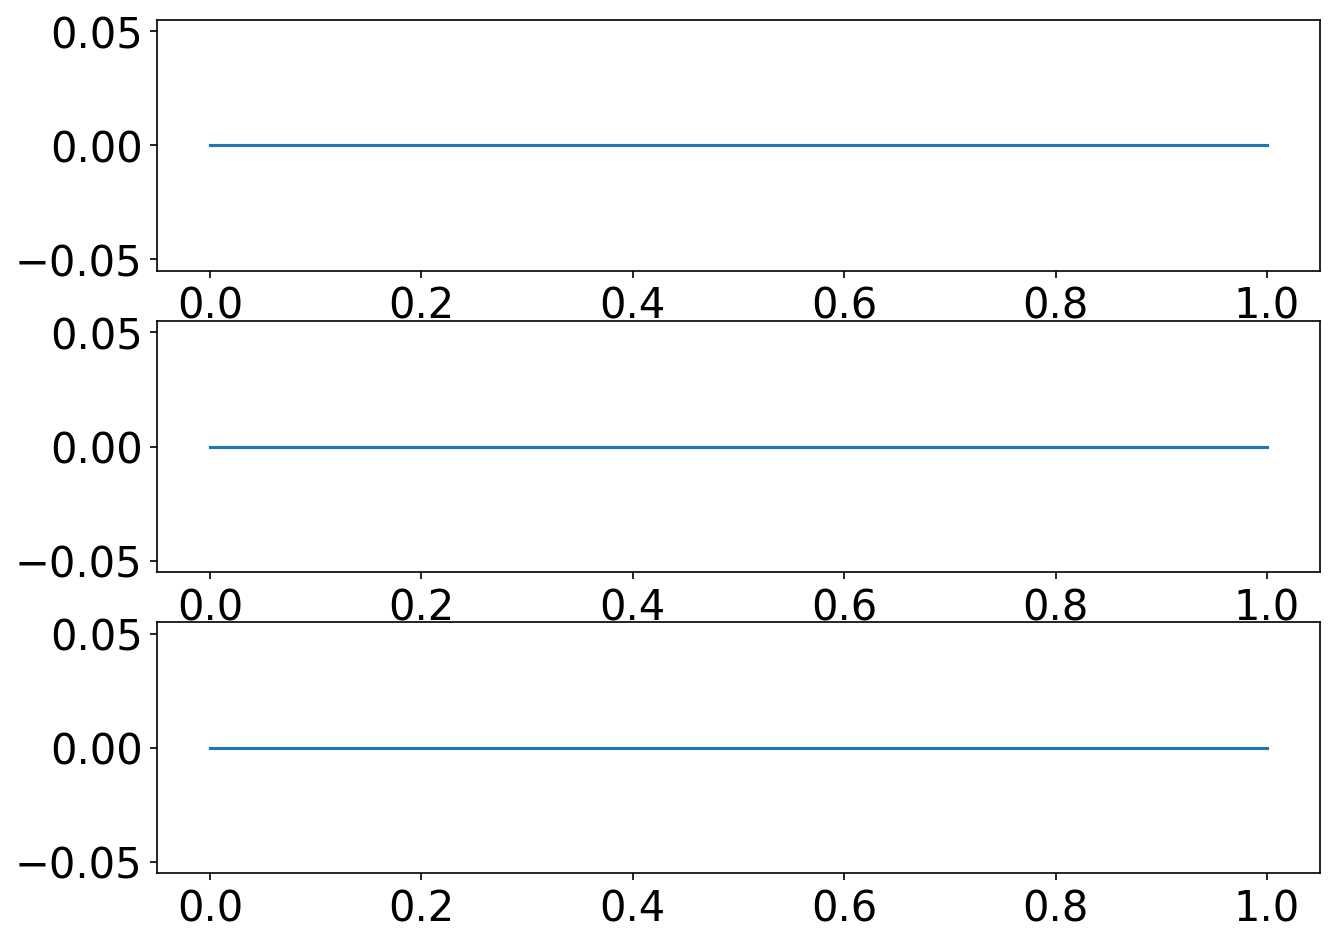

In [ ]:
plt.figure(figsize=(10, 10))
plt.subplot(4, 1, 1)
plt.plot(vacuum_time, vacuum_psi[0])
plt.subplot(4, 1, 2)
plt.plot(vacuum_time, vacuum_br[0])
plt.subplot(4, 1, 3)
plt.plot(vacuum_time, vacuum_bz[0])
plt.show()


In [ ]:
print('Skipped batch operation-stability figure export: external Excel/ODS inputs are not available in this environment.')


Skipped batch operation-stability figure export: external Excel/ODS inputs are not available in this environment.


In [ ]:
print('Skipped external VFIT_tools-based operation analysis helper definitions in this environment.')


Skipped external VFIT_tools-based operation analysis helper definitions in this environment.
